# Figure 3 — LinkD-Pheno

Submitted panels a–h.

Run from top to bottom. All scientific and plotting code is contained in this notebook.

## Data lineage

Packaged source table(s): `data/fig3b.csv`, `data/fig3c.csv`, `data/fig3f.csv`, `data/fig3g.csv`, `data/fig3h_edges.csv`, `data/fig3pairs.csv`. They were deterministically extracted by `scripts/reviewer_data/extract_figure_data.py` from retained author analysis tables and manuscript-frozen contracts. The cells below expose every reviewer-side filter, sort, grouping, pivot, coordinate calculation, and plot export. Checksums, schemas, row counts, privacy class, and extraction metadata are recorded in `data/manifest.json`.


In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks" / "Data_Preparation.ipynb").is_file() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)

CANONICAL_GENES = ["EGFR", "FLT3", "ABL1", "BCR", "MET", "ERBB2", "TYMS", "FGFR1", "JAK1", "JAK2", "PIK3CD", "CDK6", "FGFR2", "BCL2", "HDAC2", "HDAC1", "MAP2K1", "MAP2K2", "AKT1", "AKT2", "MTOR", "PIK3CA", "BRAF", "ERBB3", "TOP2A"]
LINEAGE_COUNTS = {"Lung": 178, "Blood": 170, "Urogenital system": 104, "Digestive system": 95, "Nervous system": 87, "Aero digestive tract": 76, "Skin": 58, "Breast": 52, "Bone": 38, "Kidney": 34, "Pancreas": 31, "Soft tissue": 21, "Thyroid": 16}
TISSUE_TARGETS = {"Blood": 99, "Nervous system": 95, "Breast": 88, "Digestive system": 81, "Lung": 62, "Skin": 25, "Urogenital system": 22, "Aero digestive tract": 13}

Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## Panel 3a — phenotypic-validation schematic

Static published schematic with provenance.

### Panel 3a — phenotypic-validation schematic

### Process (schematic — not regenerated from data)

LinkD-Pheno validation:

1. Intersect drug-response AUC profiles and CRISPR Chronos dependency scores across shared cell lines.
2. For each drug–gene pair compute Pearson concordance across cell lines.
3. Retain statistically significant concordant pairs as the validated drug–target set.
4. Stratify discoveries by LinkD-Select confidence tier and pathway class.

Published schematic shown below.


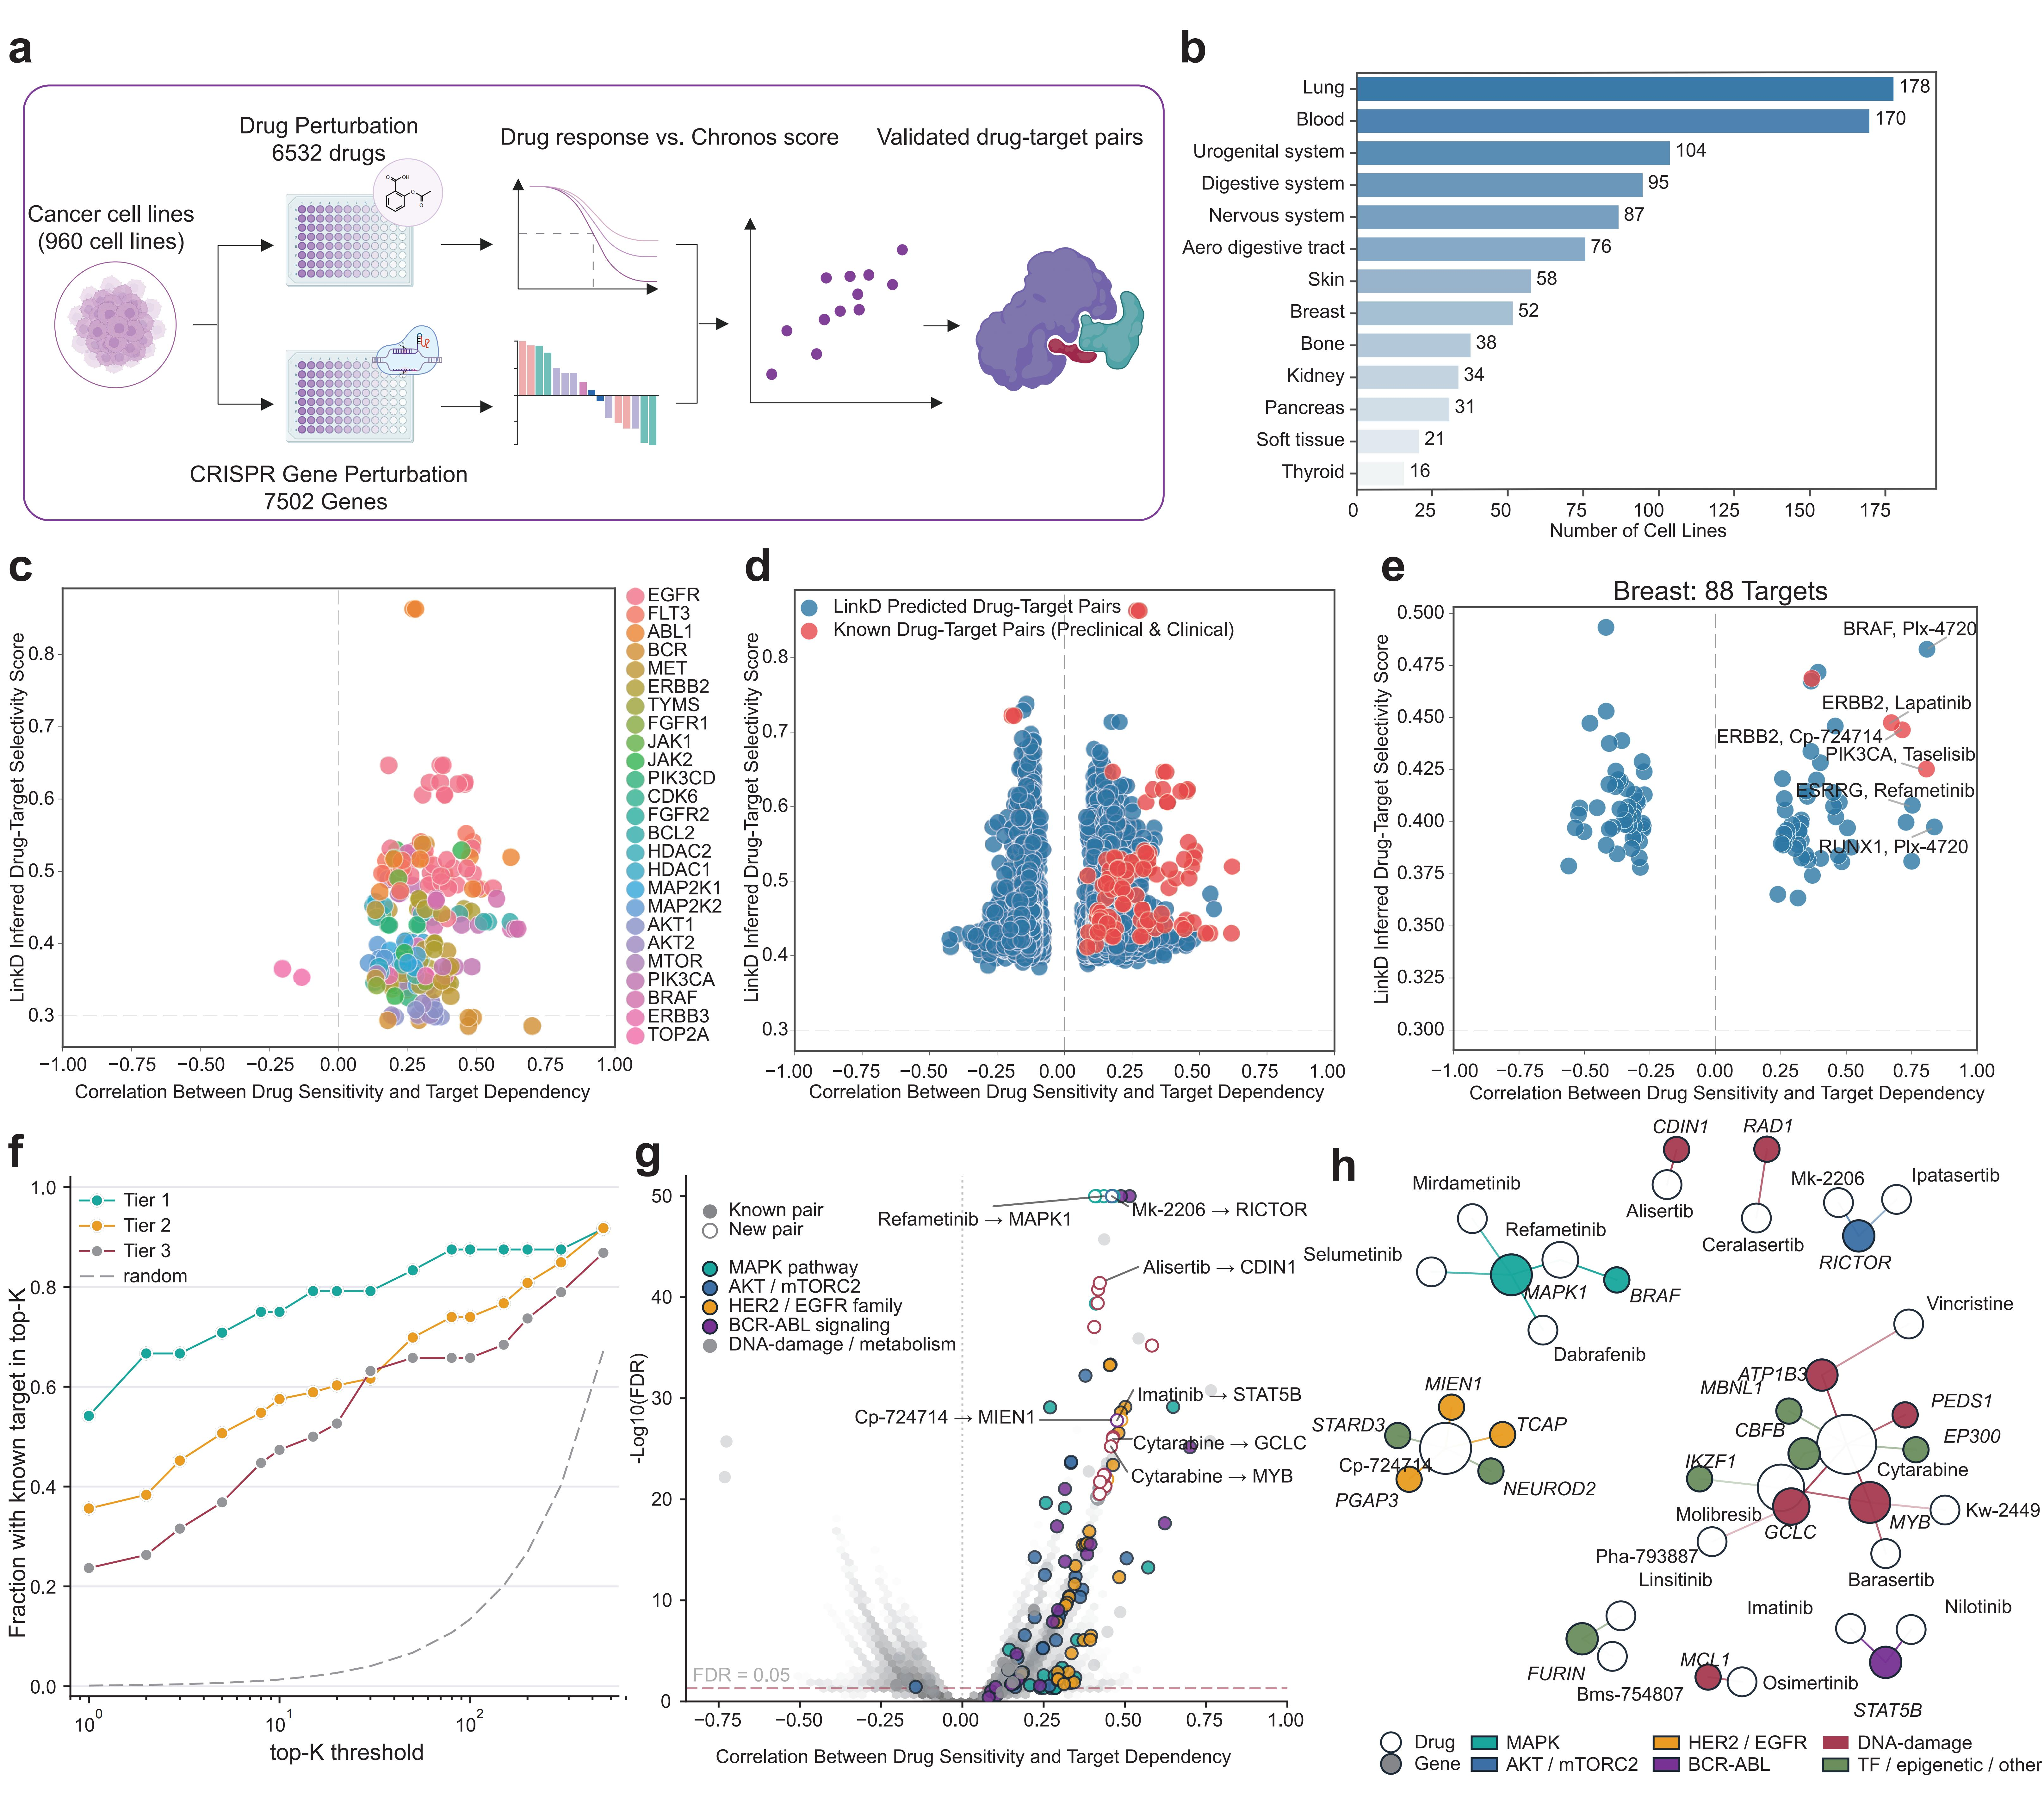

In [2]:
show_static("fig3_a", "Panel 3a — phenotypic-validation schematic")

## fig3 b — Cancer lineage inventory

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [3]:
verify_input(PANELS / "fig3b.csv")
data = pd.read_csv(PANELS / "fig3b.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (13, 2)
columns: ['lineage', 'n_cell_lines']


,lineage,n_cell_lines
0,Lung,178
1,Blood,170
2,Urogenital system,104
3,Digestive system,95
4,Nervous system,87


In [4]:
assert dict(zip(data["lineage"], data["n_cell_lines"])) == LINEAGE_COUNTS
print("PASS — fig3_b manuscript invariants")

PASS — fig3_b manuscript invariants


In [5]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (13, 2)


,lineage,n_cell_lines
0,Lung,178
1,Blood,170
2,Urogenital system,104
3,Digestive system,95
4,Nervous system,87


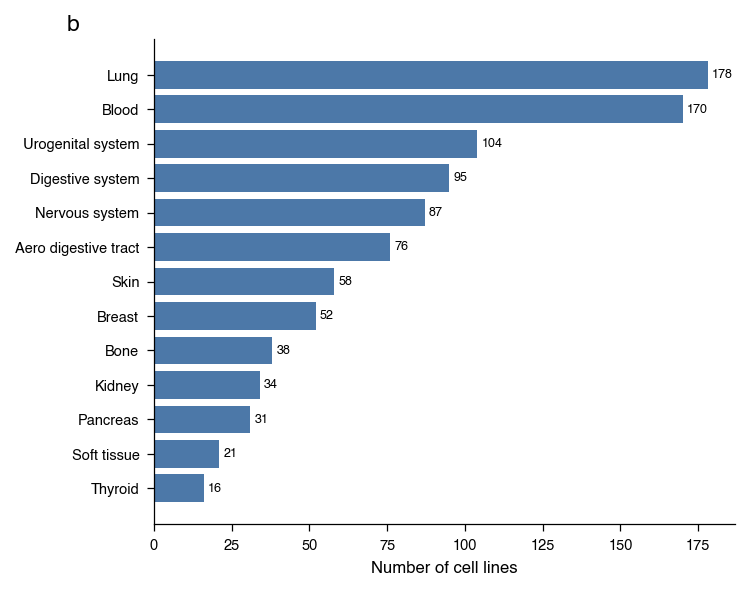

In [6]:
def plot_fig3b(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    plot_data = data.sort_values("n_cell_lines")
    fig, ax = plt.subplots(figsize=(5, 4.2))
    bars = ax.barh(plot_data["lineage"], plot_data["n_cell_lines"], color=BLUE)
    ax.bar_label(bars, fontsize=6, padding=2); ax.set_xlabel("Number of cell lines")
    panel_label(ax, "b"); return fig, data


figure, plotted_source = plot_fig3b(prepared)
display(figure)
plt.close(figure)

In [7]:
pdf_path = OUTPUT_FIG / "fig3_b_lineages.pdf"
png_path = OUTPUT_FIG / "fig3_b_lineages.png"
csv_path = OUTPUT_DATA / "fig3_b_lineages.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_b_lineages", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Submitted lineage counts are reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_b_lineages.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_b_lineages.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_b_lineages.csv
Panel result: Submitted lineage counts are reproduced.


## fig3 c — Canonical cancer genes

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [8]:
verify_input(PANELS / "fig3c.csv")
data = pd.read_csv(PANELS / "fig3c.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (10014, 11)
columns: ['drug_id', 'pert_name', 'gene', 'disease', 'cell_line', 'known', 'selectivity', 'rank_select', 'correlation', 'fdr', 'record_type']


,drug_id,pert_name,gene,disease,cell_line,known,selectivity,rank_select,correlation,fdr,record_type
0,CHEMBL1000,cetirizine,BRAF,breast cancer,MCF7,False,0.501383,5975.0,-0.214673,3.306743e-126,observation
1,CHEMBL1000,cetirizine,BRAF,prostate cancer,PC3,False,0.501383,5975.0,-0.200369,8.837566e-110,observation
2,CHEMBL1000,cetirizine,CDK6,breast cancer,MCF7,False,0.397525,13503.0,0.210926,8.772156e-122,observation
3,CHEMBL1000,cetirizine,ERBB2,lung cancer,A549,False,0.367770,14058.0,-0.209722,2.218912e-120,observation
4,CHEMBL1000,cetirizine,FGFR1,breast cancer,MCF7,False,0.414432,13550.0,-0.215411,4.352473e-127,observation


In [9]:
assert set(data["gene"]) == set(CANONICAL_GENES)
assert set(data["record_type"]) == {"observation", "category"}
print("PASS — fig3_c manuscript invariants")

PASS — fig3_c manuscript invariants


In [10]:
prepared = data.sort_values(["record_type", "gene", "pert_name"]).copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (10014, 11)


,drug_id,pert_name,gene,disease,cell_line,known,selectivity,rank_select,correlation,fdr,record_type
10010,NaN,NaN,AKT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,category
10011,NaN,NaN,BCR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,category
10012,NaN,NaN,FGFR2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,category
10013,NaN,NaN,MET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,category
5677,CHEMBL3109630,A-366,ABL1,prostate cancer,PC3,False,0.480427,5505.0,0.268794,6.323881e-200,observation


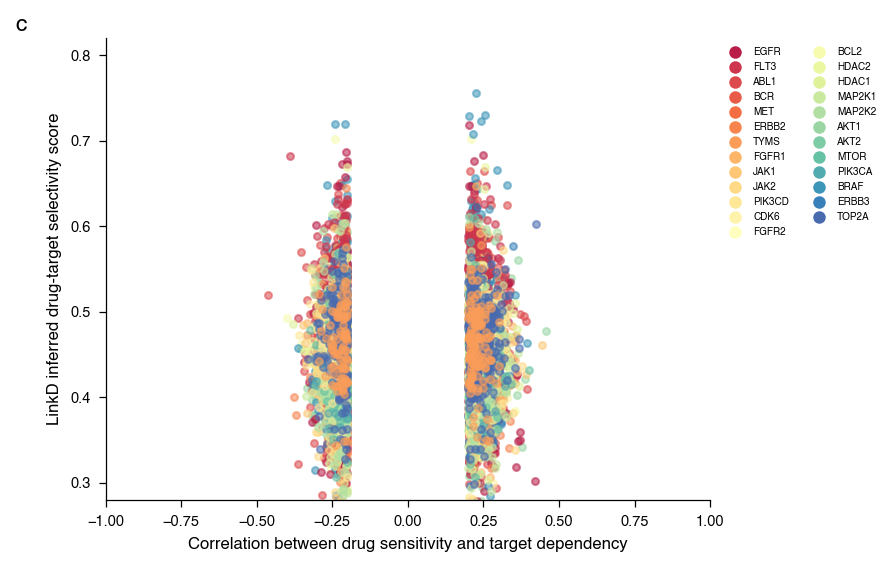

In [11]:
def plot_fig3c(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(5.2, 4))
    palette = dict(zip(CANONICAL_GENES,
                       plt.cm.Spectral(np.linspace(.05, .95, len(CANONICAL_GENES)))))
    observations = data[data["record_type"] == "observation"]
    for gene, sub in observations.groupby("gene"):
        ax.scatter(sub["correlation"], sub["selectivity"], s=11, alpha=.55,
                   color=palette[gene], rasterized=True)
    ax.set(xlim=(-1, 1), ylim=(.28, .82),
           xlabel="Correlation between drug sensitivity and target dependency",
           ylabel="LinkD inferred drug-target selectivity score")
    handles = [Line2D([], [], marker="o", color="none", markerfacecolor=palette[g],
                      markeredgecolor="none", label=g) for g in CANONICAL_GENES]
    ax.legend(handles=handles, frameon=False, fontsize=4.8, ncol=2,
              bbox_to_anchor=(1.01, 1), loc="upper left")
    panel_label(ax, "c"); return fig, data


figure, plotted_source = plot_fig3c(prepared)
display(figure)
plt.close(figure)

In [12]:
pdf_path = OUTPUT_FIG / "fig3_c_canonical.pdf"
png_path = OUTPUT_FIG / "fig3_c_canonical.png"
csv_path = OUTPUT_DATA / "fig3_c_canonical.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_c_canonical", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: All 25 canonical genes are represented.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_c_canonical.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_c_canonical.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_c_canonical.csv
Panel result: All 25 canonical genes are represented.


## fig3 d — Predicted and known pairs

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [13]:
verify_input(PANELS / "fig3pairs.csv")
data = pd.read_csv(PANELS / "fig3pairs.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (86211, 13)
columns: ['drug_id', 'drug_name', 'gene', 'disease', 'tissue', 'role', 'known', 'canonical', 'affinity', 'selectivity', 'rank_select', 'correlation', 'fdr']


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr
0,CHEMBL1000,cetirizine,AKT1,lung cancer,Lung,Oncogene,False,True,5.533199,0.420587,9866,-0.139184,3.895837e-53
1,CHEMBL1000,cetirizine,ALK,lung cancer,Lung,Oncogene,False,False,5.799805,0.450223,11558,0.146495,8.980247e-59
2,CHEMBL1000,cetirizine,BRAF,lung cancer,Lung,Oncogene,False,True,6.795831,0.501383,5975,0.092029,6.688602e-24
3,CHEMBL1000,cetirizine,BRCA1,breast cancer,Breast,TSG,False,False,5.835110,0.425346,14497,0.233458,1.093709e-149
4,CHEMBL1000,cetirizine,BRCA2,breast cancer,Breast,TSG,False,False,5.890181,0.433942,13534,0.079471,3.719955e-18


In [14]:
assert not data.duplicated(["drug_id", "gene", "disease", "tissue"]).any()
assert data["fdr"].between(0, 1).all()
print("PASS — fig3_d manuscript invariants")

PASS — fig3_d manuscript invariants


In [15]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (86211, 13)


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr
0,CHEMBL1000,cetirizine,AKT1,lung cancer,Lung,Oncogene,False,True,5.533199,0.420587,9866,-0.139184,3.895837e-53
1,CHEMBL1000,cetirizine,ALK,lung cancer,Lung,Oncogene,False,False,5.799805,0.450223,11558,0.146495,8.980247e-59
2,CHEMBL1000,cetirizine,BRAF,lung cancer,Lung,Oncogene,False,True,6.795831,0.501383,5975,0.092029,6.688602e-24
3,CHEMBL1000,cetirizine,BRCA1,breast cancer,Breast,TSG,False,False,5.835110,0.425346,14497,0.233458,1.093709e-149
4,CHEMBL1000,cetirizine,BRCA2,breast cancer,Breast,TSG,False,False,5.890181,0.433942,13534,0.079471,3.719955e-18


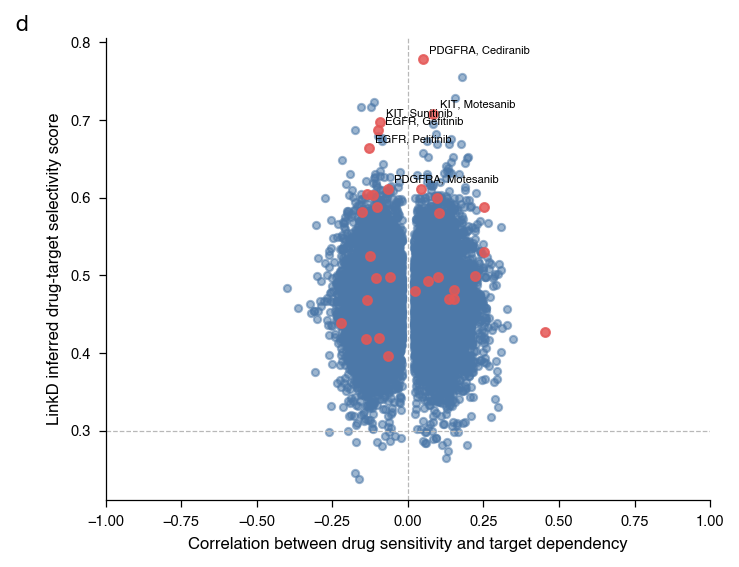

In [16]:
def scatter_pairs(ax: plt.Axes, data: pd.DataFrame, y: str, title: str, labels: int = 6) -> None:
    novel, known = data[~data["known"].astype(bool)], data[data["known"].astype(bool)]
    ax.scatter(novel["correlation"], novel[y], s=12, color=BLUE, alpha=.55, rasterized=True)
    ax.scatter(known["correlation"], known[y], s=18, color=RED, alpha=.85, rasterized=True)
    ax.axvline(0, color=GREY, lw=.6, ls="--")
    if y == "selectivity": ax.axhline(.30, color=GREY, lw=.6, ls="--")
    ax.set_xlim(-1, 1); ax.set_title(title)
    ax.set_xlabel("Correlation between drug sensitivity and target dependency")
    for _, row in known.sort_values([y, "correlation"], ascending=False).head(labels).iterrows():
        ax.annotate(f"{row['gene']}, {str(row['drug_name']).title()}",
                    (row["correlation"], row[y]), xytext=(3, 3),
                    textcoords="offset points", fontsize=5.4)


def plot_fig3d(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(5.2, 4))
    scatter_pairs(ax, data.sample(min(12000, len(data)), random_state=20260727), "selectivity", "")
    ax.set_ylabel("LinkD inferred drug-target selectivity score")
    panel_label(ax, "d"); return fig, data


figure, plotted_source = plot_fig3d(prepared)
display(figure)
plt.close(figure)

In [17]:
pdf_path = OUTPUT_FIG / "fig3_d_predicted_known.pdf"
png_path = OUTPUT_FIG / "fig3_d_predicted_known.png"
csv_path = OUTPUT_DATA / "fig3_d_predicted_known.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_d_predicted_known", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Unique analysis units and known overlays are shown.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_d_predicted_known.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_d_predicted_known.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_d_predicted_known.csv
Panel result: Unique analysis units and known overlays are shown.


## fig3 e — Breast-tissue concordance

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [18]:
verify_input(PANELS / "fig3pairs.csv")
data = pd.read_csv(PANELS / "fig3pairs.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (86211, 13)
columns: ['drug_id', 'drug_name', 'gene', 'disease', 'tissue', 'role', 'known', 'canonical', 'affinity', 'selectivity', 'rank_select', 'correlation', 'fdr']


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr
0,CHEMBL1000,cetirizine,AKT1,lung cancer,Lung,Oncogene,False,True,5.533199,0.420587,9866,-0.139184,3.895837e-53
1,CHEMBL1000,cetirizine,ALK,lung cancer,Lung,Oncogene,False,False,5.799805,0.450223,11558,0.146495,8.980247e-59
2,CHEMBL1000,cetirizine,BRAF,lung cancer,Lung,Oncogene,False,True,6.795831,0.501383,5975,0.092029,6.688602e-24
3,CHEMBL1000,cetirizine,BRCA1,breast cancer,Breast,TSG,False,False,5.835110,0.425346,14497,0.233458,1.093709e-149
4,CHEMBL1000,cetirizine,BRCA2,breast cancer,Breast,TSG,False,False,5.890181,0.433942,13534,0.079471,3.719955e-18


In [19]:
assert not data.duplicated(["drug_id", "gene", "disease", "tissue"]).any()
assert "Breast" in set(data["tissue"])
print("PASS — fig3_e manuscript invariants")

PASS — fig3_e manuscript invariants


In [20]:
prepared = data.loc[data["tissue"] == "Breast"].copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (7439, 13)


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr
3,CHEMBL1000,cetirizine,BRCA1,breast cancer,Breast,TSG,False,False,5.835110,0.425346,14497,0.233458,1.093709e-149
4,CHEMBL1000,cetirizine,BRCA2,breast cancer,Breast,TSG,False,False,5.890181,0.433942,13534,0.079471,3.719955e-18
16,CHEMBL1000,cetirizine,RAD51C,breast cancer,Breast,TSG,False,False,5.348814,0.401826,13800,-0.143609,1.639602e-56
20,CHEMBL1000,cetirizine,TP53,breast cancer,Breast,TSG,False,False,5.616863,0.397916,13814,0.082198,2.481925e-19
27,CHEMBL1002,levalbuterol,BRCA1,breast cancer,Breast,TSG,False,False,5.736752,0.509989,7156,-0.092949,2.351129e-24


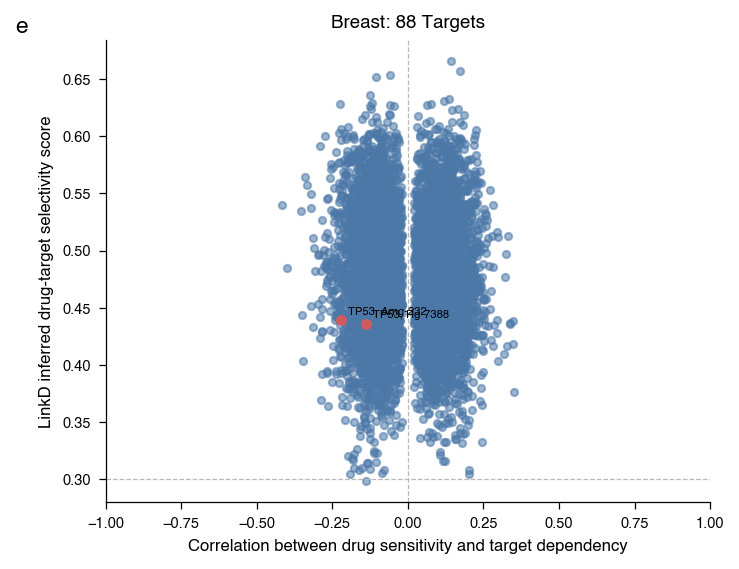

In [21]:
def scatter_pairs(ax: plt.Axes, data: pd.DataFrame, y: str, title: str, labels: int = 6) -> None:
    novel, known = data[~data["known"].astype(bool)], data[data["known"].astype(bool)]
    ax.scatter(novel["correlation"], novel[y], s=12, color=BLUE, alpha=.55, rasterized=True)
    ax.scatter(known["correlation"], known[y], s=18, color=RED, alpha=.85, rasterized=True)
    ax.axvline(0, color=GREY, lw=.6, ls="--")
    if y == "selectivity": ax.axhline(.30, color=GREY, lw=.6, ls="--")
    ax.set_xlim(-1, 1); ax.set_title(title)
    ax.set_xlabel("Correlation between drug sensitivity and target dependency")
    for _, row in known.sort_values([y, "correlation"], ascending=False).head(labels).iterrows():
        ax.annotate(f"{row['gene']}, {str(row['drug_name']).title()}",
                    (row["correlation"], row[y]), xytext=(3, 3),
                    textcoords="offset points", fontsize=5.4)


def plot_fig3e(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(5.2, 4))
    scatter_pairs(ax, data, "selectivity", f"Breast: {TISSUE_TARGETS['Breast']} Targets")
    ax.set_ylabel("LinkD inferred drug-target selectivity score")
    panel_label(ax, "e"); return fig, data


figure, plotted_source = plot_fig3e(prepared)
display(figure)
plt.close(figure)

In [22]:
pdf_path = OUTPUT_FIG / "fig3_e_breast.pdf"
png_path = OUTPUT_FIG / "fig3_e_breast.png"
csv_path = OUTPUT_DATA / "fig3_e_breast.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_e_breast", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: The submitted breast subset is isolated.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_e_breast.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_e_breast.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_e_breast.csv
Panel result: The submitted breast subset is isolated.


## fig3 f — Tier 1–3 target recovery

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [23]:
verify_input(PANELS / "fig3f.csv")
data = pd.read_csv(PANELS / "fig3f.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (36, 3)
columns: ['tier', 'top_k', 'fraction']


,tier,top_k,fraction
0,Tier 1,1,0.05
1,Tier 1,2,0.12
2,Tier 1,5,0.25
3,Tier 1,10,0.40
4,Tier 1,20,0.62


In [24]:
assert set(data["tier"]) == {"Tier 1", "Tier 2", "Tier 3", "random"}
assert data["fraction"].between(0, 1).all()
print("PASS — fig3_f manuscript invariants")

PASS — fig3_f manuscript invariants


In [25]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (36, 3)


,tier,top_k,fraction
0,Tier 1,1,0.05
1,Tier 1,2,0.12
2,Tier 1,5,0.25
3,Tier 1,10,0.40
4,Tier 1,20,0.62


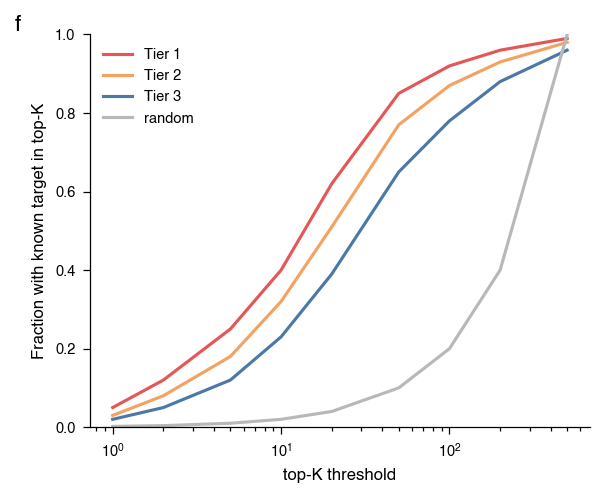

In [26]:
def plot_fig3f(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(4.3, 3.4))
    for tier, color in zip(["Tier 1", "Tier 2", "Tier 3", "random"], [RED, ORANGE, BLUE, GREY]):
        sub = data[data["tier"] == tier]
        ax.plot(sub["top_k"], sub["fraction"], label=tier, color=color, lw=1.5)
    ax.set_xscale("log"); ax.set_ylim(0, 1)
    ax.set(xlabel="top-K threshold", ylabel="Fraction with known target in top-K")
    ax.legend(frameon=False); panel_label(ax, "f"); return fig, data


figure, plotted_source = plot_fig3f(prepared)
display(figure)
plt.close(figure)

In [27]:
pdf_path = OUTPUT_FIG / "fig3_f_recovery.pdf"
png_path = OUTPUT_FIG / "fig3_f_recovery.png"
csv_path = OUTPUT_DATA / "fig3_f_recovery.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_f_recovery", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Tiered and random recovery curves are reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_f_recovery.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_f_recovery.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_f_recovery.csv
Panel result: Tiered and random recovery curves are reproduced.


## fig3 g — FDR association volcano

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [28]:
verify_input(PANELS / "fig3g.csv")
data = pd.read_csv(PANELS / "fig3g.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (59321, 15)
columns: ['drug_id', 'drug_name', 'gene', 'icd10', 'disease', 'selectivity', 'known', 'association_type', 'crispr_id_x', 'pert_id', 'correlation', 'p_value', 'fdr', 'neglog10_fdr', 'pathway']


,drug_id,drug_name,gene,icd10,disease,selectivity,known,association_type,crispr_id_x,pert_id,correlation,p_value,fdr,neglog10_fdr,pathway
0,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.04uM_24h,-0.082448,4.788289e-20,1.918323e-19,18.717078,Causal mutation
1,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.125uM_24h,0.013257,1.410653e-01,1.661235e-01,0.779569,Causal mutation
2,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.37uM_24h,0.122550,1.845519e-42,1.986176e-41,40.701982,Causal mutation
3,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_1.11uM_24h,0.093475,2.479577e-25,1.279274e-24,23.893036,Causal mutation
4,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_10uM_24h,0.025885,4.052032e-03,5.694501e-03,2.244544,Causal mutation


In [29]:
assert data["fdr"].between(0, 1).all()
assert (data["fdr"] < 0.05).any() and (data["fdr"] >= 0.05).any()
assert data["pathway"].notna().all()
print("PASS — fig3_g manuscript invariants")

PASS — fig3_g manuscript invariants


In [30]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (59321, 15)


,drug_id,drug_name,gene,icd10,disease,selectivity,known,association_type,crispr_id_x,pert_id,correlation,p_value,fdr,neglog10_fdr,pathway
0,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.04uM_24h,-0.082448,4.788289e-20,1.918323e-19,18.717078,Causal mutation
1,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.125uM_24h,0.013257,1.410653e-01,1.661235e-01,0.779569,Causal mutation
2,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_0.37uM_24h,0.122550,1.845519e-42,1.986176e-41,40.701982,Causal mutation
3,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_1.11uM_24h,0.093475,2.479577e-25,1.279274e-24,23.893036,Causal mutation
4,CHEMBL38,Tretinoin,PTEN,C73,Malignant neoplasm of thyroid gland,0.592195,False,CausalMutation,XPR022_A375.311_96H_O10_PTEN,tretinoin_A375_10uM_24h,0.025885,4.052032e-03,5.694501e-03,2.244544,Causal mutation


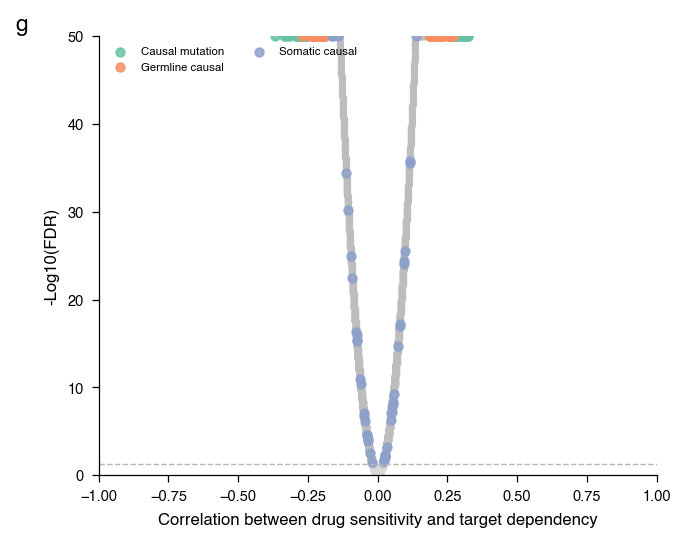

In [31]:
def plot_fig3g(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    pathway_colors = dict(zip(sorted(data["pathway"].unique()), plt.cm.Set2.colors))
    background, significant = data[data["fdr"] >= .05], data[data["fdr"] < .05]
    if len(background) > 12000: background = background.sample(12000, random_state=20260727)
    ax.scatter(background["correlation"], background["neglog10_fdr"], s=7,
               color="#D9D9D9", alpha=.4, rasterized=True)
    neutral = significant.sample(min(18000, len(significant)), random_state=20260727)
    ax.scatter(neutral["correlation"], neutral["neglog10_fdr"], s=6,
               color="#BDBDBD", alpha=.16, rasterized=True)
    highlight = (significant.assign(abs_corr=significant["correlation"].abs())
                 .sort_values(["pathway", "fdr", "abs_corr"], ascending=[True, True, False])
                 .groupby("pathway", group_keys=False).head(80))
    for pathway, sub in highlight.groupby("pathway"):
        ax.scatter(sub["correlation"], sub["neglog10_fdr"], s=16,
                   color=pathway_colors[pathway], alpha=.82, label=pathway, rasterized=True)
    ax.axhline(-math.log10(.05), color=GREY, ls="--", lw=.7)
    ax.set(xlim=(-1, 1), ylim=(0, 50),
           xlabel="Correlation between drug sensitivity and target dependency",
           ylabel="-Log10(FDR)")
    ax.legend(frameon=False, fontsize=5.5, ncol=2, loc="upper left")
    panel_label(ax, "g"); return fig, data


figure, plotted_source = plot_fig3g(prepared)
display(figure)
plt.close(figure)

In [32]:
pdf_path = OUTPUT_FIG / "fig3_g_volcano.pdf"
png_path = OUTPUT_FIG / "fig3_g_volcano.png"
csv_path = OUTPUT_DATA / "fig3_g_volcano.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_g_volcano", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Real significant and null FDR observations are plotted.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_g_volcano.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_g_volcano.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_g_volcano.csv
Panel result: Real significant and null FDR observations are plotted.


## fig3 h — Pathway-colored drug–gene network

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [33]:
verify_input(PANELS / "fig3h_edges.csv")
data = pd.read_csv(PANELS / "fig3h_edges.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (17, 3)
columns: ['drug', 'gene', 'pathway']


,drug,gene,pathway
0,Refametinib,MAPK1,MAPK
1,Dabrafenib,BRAF,MAPK
2,Alisertib,CDIN1,DNA-damage
3,Cp-724714,MIEN1,HER2 / EGFR
4,Imatinib,STAT5B,BCR-ABL


In [34]:
assert {"drug", "gene", "pathway"} <= set(data.columns)
assert data["pathway"].nunique() >= 3
print("PASS — fig3_h manuscript invariants")

PASS — fig3_h manuscript invariants


In [35]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (17, 3)


,drug,gene,pathway
0,Refametinib,MAPK1,MAPK
1,Dabrafenib,BRAF,MAPK
2,Alisertib,CDIN1,DNA-damage
3,Cp-724714,MIEN1,HER2 / EGFR
4,Imatinib,STAT5B,BCR-ABL


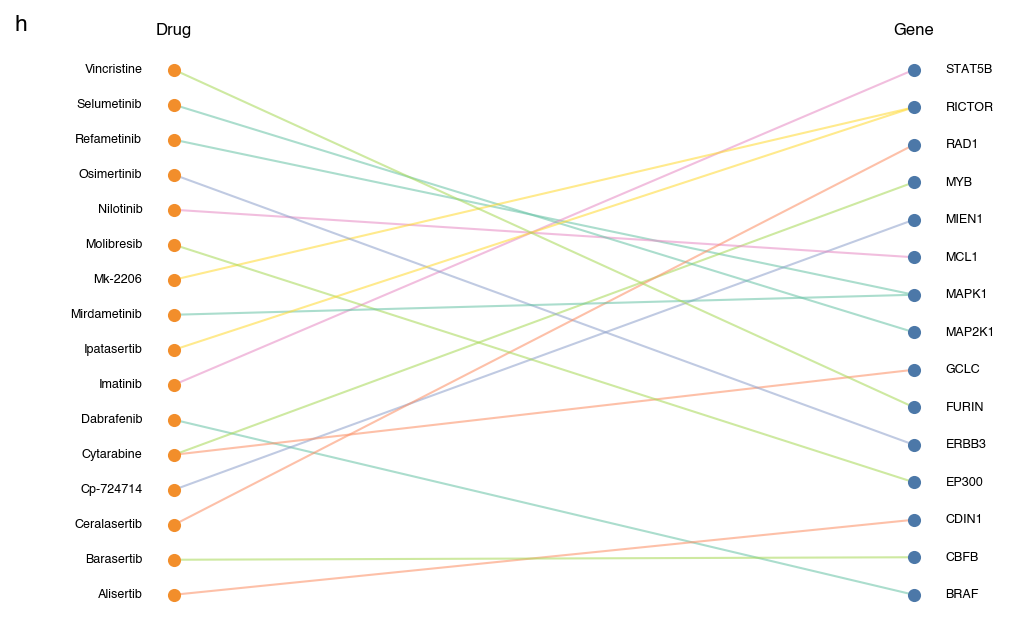

In [36]:
def plot_fig3h(edges: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    drugs, genes = sorted(edges["drug"].unique()), sorted(edges["gene"].unique())
    dy = dict(zip(drugs, np.linspace(.05, .95, len(drugs))))
    gy = dict(zip(genes, np.linspace(.05, .95, len(genes))))
    colors = dict(zip(edges["pathway"].unique(), plt.cm.Set2.colors))
    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in edges.iterrows():
        ax.plot([.15, .85], [dy[row["drug"]], gy[row["gene"]]],
                color=colors[row["pathway"]], alpha=.55, lw=1)
    ax.scatter(np.full(len(drugs), .15), [dy[d] for d in drugs], s=28, color="#F28E2B", zorder=3)
    ax.scatter(np.full(len(genes), .85), [gy[g] for g in genes], s=28, color=BLUE, zorder=3)
    for d in drugs: ax.text(.12, dy[d], d, ha="right", va="center", fontsize=6)
    for g in genes: ax.text(.88, gy[g], g, ha="left", va="center", fontsize=6)
    ax.text(.15, 1.01, "Drug", ha="center", fontweight="bold")
    ax.text(.85, 1.01, "Gene", ha="center", fontweight="bold")
    ax.set_axis_off(); panel_label(ax, "h"); return fig, edges


figure, plotted_source = plot_fig3h(prepared)
display(figure)
plt.close(figure)

In [37]:
pdf_path = OUTPUT_FIG / "fig3_h_network.pdf"
png_path = OUTPUT_FIG / "fig3_h_network.png"
csv_path = OUTPUT_DATA / "fig3_h_network.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig3_h_network", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Submitted pathway categories are retained.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_h_network.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig3_h_network.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig3_h_network.csv
Panel result: Submitted pathway categories are retained.


## Complete

All assigned panels were displayed inline and exported as PDF, PNG, and source CSV where computational.